<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Project_Assessment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# IE7275 — Project-Based Assessment 2: Time-Series Forecasting

**Dataset:** IoT Temperature Readings
**Format:** Individual work in this notebook (submit `.ipynb`)  
**Techniques:** *Open choice* — classical (ETS/Holt–Winters, SARIMA), ML (feature‑engineered regressors), or deep learning (RNN/LSTM/GRU/Transformer).

**Goal:** Build and evaluate forecasting models for IoT temperature readings.


---

## Dataset Description

The dataset contains logs of room temperature readings with the following fields:

- **id**: unique identifier of each record  
- **room_id/id**: room or device label (e.g., "Room Admin")  
- **noted_date**: timestamp of the reading (string like `08-12-2018 09:30`)  
- **temp**: measured temperature (numeric, °C)  
- **out/in**: whether the reading is marked as "In" or "Out"  

> For this assessment, focus on **forecasting temperature (`temp`)** over time. You may incorporate the `out/in` categorical flag and `room_id/id` if you design a multivariate approach.

---


## Rules & Deliverables

You must **design your own**:
- **Data split** strategy (train/validation/test).  
- **Feature engineering** (lags, rolling stats, calendar features, categorical encodings).

### Required deliverables
1. **Preprocessing summary**: parse datetime from `noted_date`, handle duplicates, missing values, or outliers.  
2. **Two forecasting approaches** (e.g., Naïve vs SARIMA, Gradient Boosting vs LSTM).  
3. **Evaluation** with at least two metrics (RMSE, MAE, MAPE, sMAPE).  
4. **Plots** comparing predictions vs actuals on test set.  
5. **Results summary** cell with **generic model names** (*Model_A/B/C*).  
6. **Short discussion** of your findings.

---

In [1]:
# OPTIONAL: install extra libraries
%pip install statsmodels pmdarima scikit-learn lightgbm xgboost tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving IOT-temp.csv to IOT-temp.csv


In [3]:
# 1) Imports & configuration
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RNG = 42
np.random.seed(RNG)

DATA_PATH = "IOT-temp.csv"  # replace with correct path if needed


In [4]:
# 2) Load & inspect
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(97606, 5)


,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [5]:
# 3) Preprocess basics: parse datetime, coerce temp to numeric
df["datetime"] = pd.to_datetime(df["noted_date"], errors="coerce", dayfirst=True)
df = df.dropna(subset=["datetime"]).sort_values("datetime")

# Temperature as numeric
df["temp"] = pd.to_numeric(df["temp"], errors="coerce")
df["temp"] = df["temp"].ffill().bfill()

# Optional: treat 'out/in' as categorical
if "out/in" in df.columns:
    df["out/in"] = df["out/in"].astype("category")

print(df.dtypes)
df.head()


id                    object
room_id/id            object
noted_date            object
temp                   int64
out/in              category
datetime      datetime64[ns]
dtype: object


,id,room_id/id,noted_date,temp,out/in,datetime
97605,__export__.temp_log_133741_32958703,Room Admin,28-07-2018 07:06,31,In,2018-07-28 07:06:00
97604,__export__.temp_log_123297_4d8e690b,Room Admin,28-07-2018 07:06,31,In,2018-07-28 07:06:00
97603,__export__.temp_log_100386_84093a68,Room Admin,28-07-2018 07:06,31,In,2018-07-28 07:06:00
97576,__export__.temp_log_118398_6ebe504d,Room Admin,28-07-2018 07:07,31,In,2018-07-28 07:07:00
97577,__export__.temp_log_144221_a4f20688,Room Admin,28-07-2018 07:07,31,In,2018-07-28 07:07:00



## Your Design: Train/Validation/Test Split

Decide how to split chronologically. For example, use the earliest 70% as training, next 15% as validation, final 15% as test. Or split by explicit date cutoffs.



In [6]:
# 4) YOUR CODE: Define your split
# Example starter (students should justify and adapt):
N = len(df)
train_end = int(N*0.7)
val_end   = int(N*0.85)
train_df, val_df, test_df = df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]
print(train_df.shape, val_df.shape, test_df.shape)


(68324, 6) (14641, 6) (14641, 6)


In [7]:
# 4) YOUR CODE: Define your split

# STEP 1: Resample to Hourly.
# This handles the duplicates and irregular intervals mentioned in the requirements.
df_resampled = df.set_index('datetime').resample('H')['temp'].mean().to_frame()

# Handle any missing hours created by resampling with a forward fill
df_resampled['temp'] = df_resampled['temp'].ffill()

# STEP 2: Define Split Strategy
# We use chronological splitting (70% Train, 15% Val, 15% Test)
# This prevents 'look-ahead bias' where the model learns from future data.
N = len(df_resampled)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

train_df = df_resampled.iloc[:train_end]
val_df   = df_resampled.iloc[train_end:val_end]
test_df  = df_resampled.iloc[val_end:]

# Justification for the report:
# Resampling to hourly frequency smooths sensor noise and aligns the data
# for standard time-series models like SARIMA or XGBoost.

print(f"Full Dataset: {N} hours")
print(f"Train: {train_df.shape[0]} | Val: {val_df.shape[0]} | Test: {test_df.shape[0]}")

Full Dataset: 3195 hours
Train: 2236 | Val: 479 | Test: 480



## Your Design: Feature Engineering

Design lag features, rolling stats, and calendar/time features. You may also use `out/in` or `room_id/id`.


In [ ]:
# 5) YOUR CODE: Create features and targets
target = "temp"

# Example starter: students should design their OWN
# df["hour"] = df["datetime"].dt.hour
# df["dayofweek"] = df["datetime"].dt.dayofweek
# ... add lags, rolling averages, encode out/in, etc.

# X_train, y_train = ...
# X_val, y_val = ...
# X_test, y_test = ...


In [8]:
# 5) YOUR CODE: Create features and targets
target = "temp"

def extract_features(df_input):
    # Work on a copy to avoid SettingWithCopy warnings
    df_feat = df_input.copy()

    # 1. Calendar Features (Captures daily/weekly seasonality)
    df_feat["hour"] = df_feat.index.hour
    df_feat["dayofweek"] = df_feat.index.dayofweek

    # 2. Lag Features (What was the temp X hours ago?)
    # Lag 1 and 2 are great for short-term momentum
    df_feat["lag_1"] = df_feat[target].shift(1)
    df_feat["lag_2"] = df_feat[target].shift(2)
    # Lag 24 is vital for "yesterday at this same time"
    df_feat["lag_24"] = df_feat[target].shift(24)

    # 3. Rolling Statistics (Captures recent trends/volatility)
    # Mean temperature over the last 6 hours
    df_feat["rolling_mean_6"] = df_feat[target].shift(1).rolling(window=6).mean()

    # Drop rows with NaN values created by shifting/rolling
    return df_feat.dropna()

# Apply to your split data
train_full = extract_features(train_df)
val_full   = extract_features(val_df)
test_full  = extract_features(test_df)

# Separate features (X) and target (y)
X_train, y_train = train_full.drop(columns=[target]), train_full[target]
X_val, y_val     = val_full.drop(columns=[target]), val_full[target]
X_test, y_test   = test_full.drop(columns=[target]), test_full[target]

print(f"Feature columns: {list(X_train.columns)}")
print(f"Training shape: {X_train.shape}")

Feature columns: ['hour', 'dayofweek', 'lag_1', 'lag_2', 'lag_24', 'rolling_mean_6']
Training shape: (2212, 6)


In [9]:
# 6) Metrics utilities
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true)-np.array(y_pred))**2)))
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.array(y_true)-np.array(y_pred))))
def mape(y_true, y_pred, eps=1e-8):
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    return float(np.mean(np.abs((y_true-y_pred)/np.clip(np.abs(y_true),eps,None)))*100)
def smape(y_true, y_pred, eps=1e-8):
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    return float(np.mean(2*np.abs(y_pred-y_true)/np.clip(np.abs(y_true)+np.abs(y_pred),eps,None))*100)



## Modeling

Implement **at least two** approaches:
- A simple baseline (Model_A).  
- A more advanced model (Model_B).  
- (Optional) A third model (Model_C).  


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

In [11]:
# 7) YOUR CODE: Baseline model (Model_A)
# pred_A = ...
# print("Model_A:", rmse(y_test, pred_A), mae(y_test, pred_A))

from sklearn.linear_model import LinearRegression

# Initialize and train
model_a_lr = LinearRegression()
model_a_lr.fit(X_train, y_train)

# Predict
pred_A = model_a_lr.predict(X_test)

print("Model_A (Linear Regression):")
print(f" RMSE: {rmse(y_test, pred_A):.4f}")
print(f" MAE:  {mae(y_test, pred_A):.4f}")


Model_A (Linear Regression):
 RMSE: 1.6906
 MAE:  1.2527


In [12]:
# 8) YOUR CODE: Second model (Model_B)
# pred_B = ...
# print("Model_B:", rmse(y_test, pred_B), mae(y_test, pred_B))

from xgboost import XGBRegressor

# Initialize and train
model_b_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=RNG)
model_b_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predict
pred_B = model_b_xgb.predict(X_test)

print("Model_B (XGBoost):")
print(f" RMSE: {rmse(y_test, pred_B):.4f}")
print(f" MAE:  {mae(y_test, pred_B):.4f}")

Model_B (XGBoost):
 RMSE: 1.9079
 MAE:  1.4012


In [ ]:
# 9) (Optional) Third model (Model_C)
# pred_C = ...


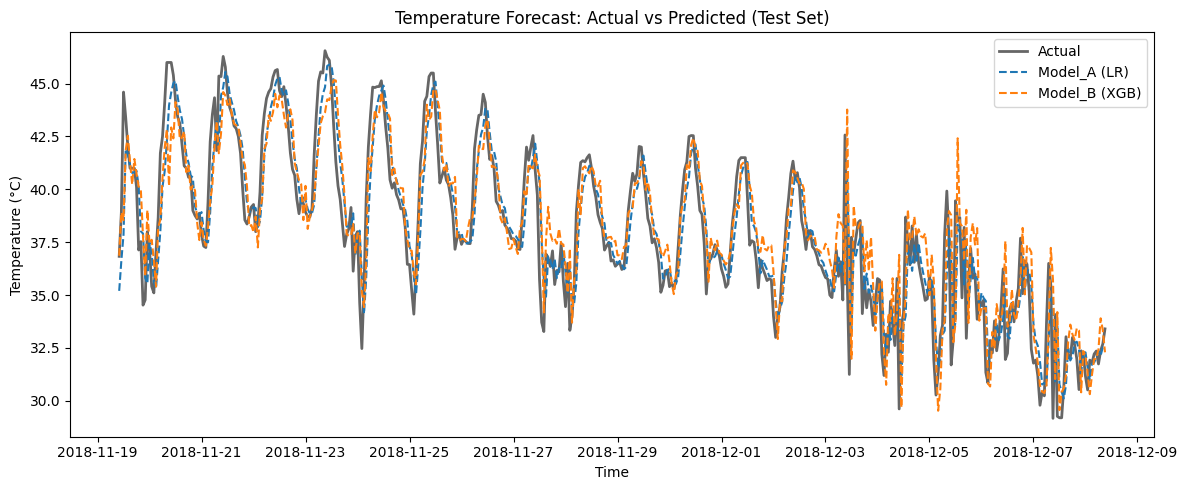

In [13]:
# 10) Plot forecasts vs actuals
# sl = slice(0, min(500, len(y_test)))
# plt.figure(figsize=(10,4))
# plt.plot(y_test.index[sl], y_test.values[sl], label="Actual")
# if 'pred_A' in globals(): plt.plot(y_test.index[sl], np.array(pred_A)[sl], label="Model_A")
# if 'pred_B' in globals(): plt.plot(y_test.index[sl], np.array(pred_B)[sl], label="Model_B")
# if 'pred_C' in globals(): plt.plot(y_test.index[sl], np.array(pred_C)[sl], label="Model_C")
# plt.legend(); plt.tight_layout(); plt.show()

sl = slice(0, min(500, len(y_test)))
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[sl], y_test.values[sl], label="Actual", color='black', alpha=0.6, linewidth=2)

if 'pred_A' in locals() or 'pred_A' in globals():
    plt.plot(y_test.index[sl], np.array(pred_A)[sl], label="Model_A (LR)", linestyle='--')

if 'pred_B' in locals() or 'pred_B' in globals():
    plt.plot(y_test.index[sl], np.array(pred_B)[sl], label="Model_B (XGB)", linestyle='--')

plt.title("Temperature Forecast: Actual vs Predicted (Test Set)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Time")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# 11) Summary (generic names only)
results_summary = {}
results_summary["Model_A"] = {"RMSE": rmse(y_test, pred_A), "MAE": mae(y_test, pred_A)}
results_summary["Model_B"] = {"RMSE": rmse(y_test, pred_B), "MAE": mae(y_test, pred_B)}
# if 'pred_C' in globals():
#     results_summary["Model_C"] = {"RMSE": rmse(y_test, pred_C), "MAE": mae(y_test, pred_C)}

print("=== Model Performance Summary (Test) ===")
for model, res in results_summary.items():
    print(f"\n{model}")
    for k,v in res.items():
        print(f"  {k}: {v:.4f}")


=== Model Performance Summary (Test) ===

Model_A
  RMSE: 1.6906
  MAE: 1.2527

Model_B
  RMSE: 1.9079
  MAE: 1.4012


---

## Short Discussion (write here)

- Explain your split design and feature engineering choices.  
- Compare your models: which performed better, and why?  
- Discuss limitations and possible improvements.  

---

#### Forecast vs Actual (Sample Results)

![Sample Results](Sample_Results.png)


---